# 16.1.2 执行饱和、初值与适用域

## 学习目标与先修知识

把实际限幅输入（input）代回方程，比较不同初值（initial condition）的恢复与离开。

先修：16.1.1 能量下降；显式 Euler 与初值。

## 具体问题

未饱和推导成立，实际执行器只能提供有限输入。小扰动恢复是否足以称系统全局稳定？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
for x in [.3,1.5]:print("x",x,"请求",-0.8*x-1.2*x**3,"限幅后",np.clip(-0.8*x-1.2*x**3,-.5,.5))

x 0.3 请求 -0.2724 限幅后 -0.2724
x 1.5 请求 -5.25 限幅后 -0.5


## 模型假设

真实输入 $u_{\rm act}=\operatorname{clip}(u_{\rm req},-u_{\max},u_{\max})$；采用固定步长计算三组初态的轨迹（trajectory），再结合能量导数（derivative）解释状态（state）的运动方向。

## 数学解释与推导

实际能量导数（derivative）为 $x[-ax+\beta x^3+u_{\rm act}(x)]$。限幅后不能再将 $u_{\rm act}$ 替换为请求输入；对足够大的正 x，三次正反馈（positive feedback）可能压过固定上限。有限轨迹可给出反例和适用域线索，却不能单凭扫描证明连续系统的完整吸引域（basin of attraction）。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def nonlinear_feedback(x,a,beta,k,c,limit):
    requested=-k*x-c*x**3
    applied=float(np.clip(requested,-limit,limit))
    derivative=-a*x+beta*x**3+applied
    return [float(requested),applied,float(derivative),float(x*derivative)]


def nonlinear_path(x0,a,beta,k,c,limit,h,steps):
    states=[float(x0)];inputs=[]
    for _ in range(steps):
        _,u,derivative,_=nonlinear_feedback(states[-1],a,beta,k,c,limit)
        inputs.append(u);states.append(states[-1]+h*derivative)
    return [states,inputs]

## 对照实验

固定控制律与执行上限，只改变初态为 0.3、1.2、1.5 U，观察各轨迹开始向内恢复还是向外移动。

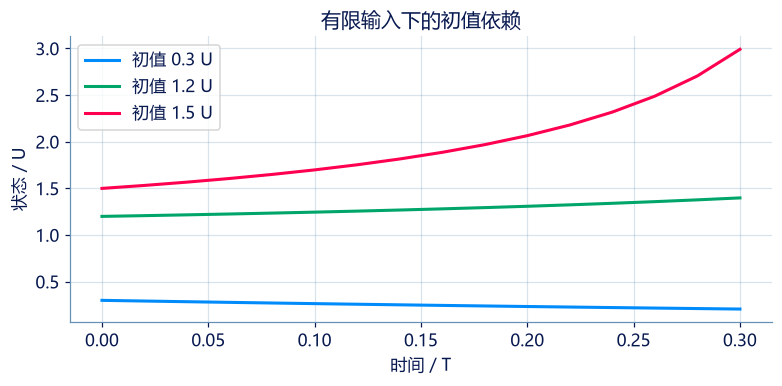

In [4]:
fig,ax=plt.subplots(figsize=(7,3.4))
for x0,color in [(.3,BLUE),(1.2,GREEN),(1.5,PINK)]:
    path=np.asarray(nonlinear_path(x0,.4,.8,.8,1.2,.5,.02,15)[0]);ax.plot(np.arange(len(path))*.02,path,label=f"初值 {x0} U",color=color)
ax.set(xlabel="时间 / T",ylabel="状态 / U",title="有限输入下的初值依赖");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

图只展示0.3 个时间单位内的离散轨迹；高初值可能朝外运动。若把执行限幅忽略，就会错误扩大 Lyapunov 结论。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert abs(nonlinear_feedback(.1,.4,.8,.8,1.2,.5)[1])<=.5
assert abs(nonlinear_feedback(2.,.4,.8,.8,1.2,.5)[1])==.5
for x0 in [.3,1.2,1.5]:assert len(nonlinear_path(x0,.4,.8,.8,1.2,.5,.02,15)[0])==16
print("限幅和初态时序核验通过。")

限幅和初态时序核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：小扰动恢复与全局结论

限幅控制在 x0=0.3 的轨迹（trajectory）恢复，能得出什么？

- **A.** 已经证明所有初值（initial condition）都恢复。
- **B.** 可不再检查实际输入（input）。
- **C.** 只支持当前初值和模型（model）的有限轨迹观察。
- **D.** 无饱和证明自动转移。

[作答：小扰动恢复与全局结论](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-saturated-global)

### 第 2 题 · 单项选择题：有限扫描的作用

扫描若干初值（initial condition）未发现失稳，何种表述合适？

- **A.** 已经证明连续系统全局吸引。
- **B.** 可以删除未扫描区域。
- **C.** 等价于解析能量不等式。
- **D.** 给出当前范围的数值证据，仍需解析条件或更完整验证。

[作答：有限扫描的作用](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-finite-scan)

### 第 3 题 · Python 计算题：比较扰动与执行上限

计算一个指定状态（state）下的实际反馈（feedback）和 V 导数（derivative），判断当前参数（parameter）是否直接给出负导数。

**函数与代码模板**

```python
def solve(
    x: float,
    a: float,
    beta: float,
    k: float,
    c: float,
    limit: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 待检验状态。 | U |
| `a` | `float` | 线性项系数。 | 1/T |
| `beta` | `float` | 三次项系数。 | 1/(U²T) |
| `k` | `float` | 线性反馈系数。 | 1/T |
| `c` | `float` | 三次反馈系数。 | 1/(U²T) |
| `limit` | `float` | 输入（input）上限。 | U/T |

**返回值**

直接返回 result（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list[float]` | 请求输入、实际输入、状态导数、V 导数。 | 混合 |

**计算规则**

请求输入 -k*x-c*x³；实际输入截到 [-limit,limit]；状态率 -a*x+beta*x³+实际输入；V=x²/2 的变化率为 x*状态率。

**约束与边界**

- limit>0；参数和状态均为有限数值。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 待检验状态。 | 2 | U |
| a | 线性项系数。 | 1 | 1/T |
| beta | 三次项系数。 | 0.5 | 1/(U²T) |
| k | 线性反馈系数。 | 1 | 1/T |
| c | 三次反馈系数。 | 0.5 | 1/(U²T) |
| limit | 输入（input）上限。 | 0.4 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 2.0
a = 1.0
beta = 0.5
k = 1.0
c = 0.5
limit = 0.4

result = solve(x, a, beta, k, c, limit)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | 请求输入、实际输入、状态导数、V 导数。 | [-6.0, -0.4, 1.6, 3.2] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-6.0, -0.4, 1.6, 3.2]
```

**样例解释**

在 x=2 时请求输入远超上限，必须使用实际输入 -0.4 计算 V 导数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：比较扰动与执行上限](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-saturation-boundary)

### 第 4 题 · Python 计算题：有限初值的反馈实验

给定初值（initial condition）只返回该初值的 Euler 路径与实际输入（input）；不得把有限路径当成全局证明。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    beta: float,
    k: float,
    c: float,
    limit: float,
    h: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 待实验初值。 | U |
| `a` | `float` | 线性项系数。 | 1/T |
| `beta` | `float` | 三次项系数。 | 1/(U²T) |
| `k` | `float` | 线性反馈（feedback）系数。 | 1/T |
| `c` | `float` | 三次反馈系数。 | 1/(U²T) |
| `limit` | `float` | 输入上限。 | U/T |
| `h` | `float` | 步长。 | T |
| `steps` | `int` | 步数。 | 步 |

**返回值**

按以下顺序返回元组：(states, inputs)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 包含初值的路径。 | U |
| `inputs` | `list[float]` | 逐步实际输入。 | U/T |

**计算规则**

每步先按当前状态（state）求实际限幅输入，再用显式 Euler 推进；返回含初态的状态和每步实际输入。

**约束与边界**

- limit>0、h>0，0≤steps≤100；参数（parameter）和初态有限，生成路径保持有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 待实验初值。 | 0.5 | U |
| a | 线性项系数。 | 1 | 1/T |
| beta | 三次项系数。 | 0 | 1/(U²T) |
| k | 线性反馈（feedback）系数。 | 1 | 1/T |
| c | 三次反馈系数。 | 0 | 1/(U²T) |
| limit | 输入上限。 | 1 | U/T |
| h | 步长。 | 0.1 | T |
| steps | 步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 0.5
a = 1.0
beta = 0.0
k = 1.0
c = 0.0
limit = 1.0
h = 0.1
steps = 2

result = solve(x0, a, beta, k, c, limit, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 包含初值的路径。 | [0.5, 0.4, 0.32] | U |
| inputs | 逐步实际输入。 | [-0.5, -0.4] | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 0.4, 0.32], [-0.5, -0.4])
```

**样例解释**

首例未触发限幅，状态每步乘 0.8；只说明这个离散实验。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：有限初值的反馈实验](http://127.0.0.1:8000/chapters/16-01-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8F%8D%E9%A6%88%E8%AE%BE%E8%AE%A1/practice/?question=p16-region-path)

**进一步阅读**

[Boyd 等](https://web.stanford.edu/~boyd/lmibook/)讨论稳定性证据；本节不把有限扫描提升为全局保证。